# Acesso Territorial a Oportunidades

**AUTORIA:** [REDE MOB](https://www.redemob.com.br/)

Este notebook gera **mapas de calor** que mostram onde se concentram três tipos de oportunidades: (i) empregos formais, (ii) infraestrutura de saúde pública e (iii) oferta de educação básica na rede pública. Pressupõe-se que o usuário disponha dos arquivos resultantes de outros scripts constantes deste Kit. O código carrega o conjunto pertinente ao domínio escolhido (emprego, saúde ou educação), aplica filtros temáticos — nível de complexidade hospitalar ou etapa de ensino, quando solicitados — e gera mapas de acessibilidade por transporte público ou por caminhada em intervalos de tempo pré-definidos — futuras versões irão conter mecanismos para estimar mais adequadamente o acesso por transporte individual.

Além de mapear o acesso a essas oportunidades, o notebook também **relaciona cada superfície de acessibilidade à distribuição da população local por sexo, raça, renda e faixa etária**. Essa comparação, permite avaliar desigualdades socioespaciais e orientar políticas de mobilidade e inclusão.

O resultado facilita avaliações de equidade, diagnósticos de mobilidade e cálculos de acessibilidade focados nos serviços públicos essenciais.

Este caderno estima e apresenta **mapas de acessibilidade** a equipamentos **públicos** de **saúde** e **educação**, além de tabelas de síntese por recortes socioespaciais. A análise integra:
1) **oferta de oportunidades** (estabelecimentos de saúde, educação ou trabalho),
2) **rede de transporte** (caminhada e transporte coletivo, via GTFS opcional) e
3) **população** (para leitura distributiva e equidade).

> Em síntese, há fluxo único que, a partir de arquivos já processados, possibilite:  
> • **Selecionar o domínio** de análise – emprego, saúde ou educação;  
> • **Aplicar filtros temáticos** (complexidade hospitalar ou etapa escolar) quando pertinentes;  
> • **Modele a rede de transporte** a partir da rede viária e (opcionalmente) de um feed GTFS informado pelo usuário;  
> • **Calcular mapas de calor** do acesso às oportunidades públicas escolhidas;  
> • **Comparar essas densidades com camadas demográficas** (população total e recortes por sexo, raça, renda e idade) para medir quão equitativamente os serviços estão distribuídos.

## OBJETIVO

> Construir, para o conjunto de municípios analisados, indicadores de **acessibilidade a serviços públicos essenciais**, com possibilidade de filtros temáticos (níveis de ensino; complexidade hospitalar; atendimento hospitalar), informando decisões de política pública e o desenho de intervenções no sistema de transportes.

## PANORAMA

- **Entradas**
  - Do script sociodemografia.ipynb
    - *Hex grid* (H3) com população e atributos demográficos.
  - Do script rais.ipynb
    - **Educação (schools)**: colunas **binárias** por nível (`infantil`, `fundamental`, `medio`, `eja`, `profissional`) e categoria (`publica`/`privada`).
    - **Saúde (cnes)**: `vinculo_sus` (0/1), `indicador_atendimento_hospitalar` (0/1) e `nivel_complexidade` (baixa/média/alta).
  - **PBF** (OSM) para a rede viária.
  - **GTFS** por modo/operador (opcional)


- **Processamento**
  1. Seleção do **oportunidade** (emprego | educação | saúde) e aplicação de **filtros** temáticos.
  2. Harmonização e **validação de CRS** (SIRGAS 2000).
  3. Construção/validação da **rede R5** (PBF × GTFS).
  4. Cálculo de **tempos porta-a-porta** (janelas de partida) e métricas de acessibilidade.
  5. Sínteses, **mapas de calor** e exportação dos resultados.

- **Saídas**
  - `parquet` com tempos e métricas de acessibilidade.
  - Mapas (`.png/.pdf`) e tabelas de resumo por recortes territoriais.
  - Resultados salvos em `../outputs/oportunidades`

## LIMITAÇÕES

- **Cobertura de dados**: a precisão depende da atualidade e qualidade de `schools`/`cnes`, GTFS e PBF.
- **Medidas de acessibilidade**: resultados refletem parâmetros escolhidos (janela de partida, tempo máximo, velocidade de caminhada, nº máximo de transferências).
- **Filtragens temáticas**: as colunas binárias (0/1) são assumidas como limpas; valores faltantes são tratados como 0.

## COMO USAR

1. **Defina os parâmetros** na célula “Configuração” (municípios, oportunidade, filtros, caminhos de entrada, hora de partida e limites).
2. **Verifique as entradas** (célula de “Pré-voo”): existência de arquivos e, quando possível, cobertura PBF×GTFS.
3. **Execute o fluxo**: leitura → filtros → rede/tempos → métricas → mapas → exportação.
4. **Interprete os resultados** confrontando mapas de acessibilidade com distribuição populacional e atributos demográficos.

  > **Modo somente caminhada.** Se **nenhum GTFS** for fornecido, o cálculo é realizado **apenas a pé**, utilizando a rede viária do `PBF_PATH`. Nesse modo, **`MAX_WALK_TIME`** define o limite temporal da análise. O parâmetro `HORA_PARTIDA` torna-se irrelevante.

**Parâmetros Definidos Pelo Usuário**

| Parâmetro | Descrição | Exemplo / Valores |
|---|---|---|
| `MUNIS` | Lista de códigos IBGE dos municípios-alvo, que devem ser os mesmos utilizados em sociodemogragia.ipynb e rais.ipynb | `[3303302, 3304904]` |
| `CNES_MONTH` | Mês de corte do CNES (1–12) | `10` |
| `OPORTUNIDADE` | Conjunto a processar | `'emprego'` \| `'educacao'` \| `'saude'` |
| `GTFS_PATHS` | Lista de caminhos para feeds GTFS | `["data/gtfs/onibus.zip", "data/gtfs/barcas.zip"]` |
| `PBF_PATHS` | Caminho para o arquivo PBF (OSM) | `"data/osm/rmrj.pbf"` |
| `RAIS_PATH` | **Caminho do arquivo de emprego** (Parquet). | `"../outputs/rais/rais_3303302-3304904.parquet"` |
| `SCHOOLS_PATH` | **Caminho do arquivo de educação** (Parquet). | `"../outputs/rais/schools_3303302-3304904.parquet"` |
| `CNES_PATH` | **Caminho do arquivo de saúde (CNES)** (Parquet).  | `"../outputs/rais/cnes_3303302-3304904.parquet"` |
| `SOCIO_PATH` | **Arquivo socioeconômico** (Parquet, preferencialmente em H3, com população/atributos) | `"../outputs/sociodemografia/sociodemografia_hex_9_3303302-3304904.parquet"` |
| `CENSUS_YEAR` | Se utiliza dados do censo de 2010 ou de 2022 | `2010` \| `2022` |
| `HORA_PARTIDA` | Horário local de partida para a janela de cálculo | `"07:00"` |
| `MAX_TRAVEL_TIME` | Tempo máximo de viagem (minutos) | `120` |
| `MAX_WALK_TIME` | Tempo máximo de viagem (minutos) permitida a pé | `45` |


> **Observação 1.** Edite apenas esta célula de configuração no início. As demais células assumem esses valores e não exigem intervenção adicional.
> **Observação 2: Modo somente caminhada.** Se **nenhum GTFS** for fornecido (`GTFS_PATHS = []`), o cálculo é realizado **apenas a pé**, utilizando a rede viária do `PBF_PATH`. Nesse modo, **`MAX_WALK_TIME`** define o limite temporal da análise. O parâmetro `HORA_PARTIDA` torna-se irrelevante.

**Filtros Temáticos (aplicáveis quando `OPORTUNIDADE` = `educacao` ou `saude`)**

| Parâmetro | Escopo | Descrição | Exemplo / Valores |
|---|---|---|---|
| `nivel_ensino` | Educação | Lista de níveis com colunas **binárias** (`infantil`, `fundamental`, `medio`, `eja`, `profissional`). Seleciona registros que ofertam **qualquer** nível escolhido. | `["infantil", "fundamental"]` \| `"todos"` |
| `categoria_escola` | Educação | Tipo de escola | `'publica'` \| `'privada'` \| `'todas'` |
| `vinculo_sus` | Saúde | Indicador **binário** (`vinculo_sus`): `todos` (sem filtro); `publico` (== **1**); `privado` (== **0**) | `'todos'` \| `'publico'` \| `'privado'` |
| `nivel_complexidade_sel` | Saúde | Nível de complexidade do estabelecimento | `'todos'` \| `'baixa'` \| `'media'` \| `'alta'` |
| `apenas_hospital` | Saúde | Usa `indicador_atendimento_hospitalar` **binário**: se `True`, filtra `== 1`; se `False`, não filtra | `True` \| `False` |

**Exemplo mínimo de configuração**

```python
# Preferencialmente, codigos utilizados em rais.ipynb e sociodemografia.ipynb
MUNIS       = [3303302, 3304904]

# Caminhos de oportunidades. Caminhos padrão: se utilizado o repositório
# conforme fornecido, não é necessário mexer.
TAG            = "-".join(str(m) for m in MUNIS)
RAIS_PATH      = f"../outputs/rais/rais_{TAG}.parquet"
SCHOOLS_PATH   = f"../outputs/rais/schools_{TAG}.parquet"
CNES_PATH      = f"../outputs/rais/cnes_{TAG}.parquet"
SOCIO_PATH     = f"../outputs/rais/socio_{TAG}.parquet"

CENSUS_YEAR    = 2022

OPORTUNIDADE      = "saude"  # 'emprego' | 'educacao' | 'saude'

# Caminhos de rede
GTFS_PATHS  = ["data/gtfs/onibus.zip", "data/gtfs/barcas.zip"] # GTFS_PATHS = [] ativa modo somente caminhada
PBF_PATH    = "data/osm/rmrj.pbf"

# Parâmetros de rede/tempo
HORA_PARTIDA     = "05:00"
MAX_TRAVEL_TIME  = 120
MAX_WALK_TIME    = 45        # somente caminhada

# Filtros (aplicados conforme OPORTUNIDADE)
nivel_ensino            = ["infantil", "fundamental"]   # ou "todos"
categoria_escola        = "todas"
vinculo_sus             = "publico"                     # 'todos'|'publico'|'privado'
nivel_complexidade_sel  = "todos"
apenas_hospital         = False

# Preenchimento de Parâmetros Definidos Pelo Usuário

In [1]:
MUNIS       = [3304557, 3303302, 3304904, 3301900,] 

# Caminhos de oportunidades. Caminhos padrão: se utilizado o repositório
# conforme fornecido, não é necessário mexer.
TAG            = "-".join(str(m) for m in MUNIS)
RAIS_PATH      = f"../outputs/rais/rais_{TAG}.parquet"
SCHOOLS_PATH   = f"../outputs/rais/schools_{TAG}.parquet"
CNES_PATH      = f"../outputs/rais/cnes_{TAG}.parquet"
SOCIO_PATH     = f"../outputs/sociodemografia/sociodemografia_hex_r9_{TAG}.parquet"

CENSUS_YEAR    = 2022

OPORTUNIDADE      = "emprego"  # 'emprego' | 'educacao' | 'saude'

# Caminhos de rede viária
PBF_PATH  = "../database/3. Urbanísticos/rmrj.osm.pbf"

# Caminho do GTFS: se vazio GTFS_PATHS = [] => modo somente caminhada
input_dir     = "../database/4. Dados Operacionais do Transporte/GTFS" # Padrão (não mexer)
GTFS_PATHS    = [
    f"{input_dir}/Ônibus RJ/gtfs_rio-de-janeiro.zip",
    f"{input_dir}/Barcas/gtfs_barcas.zip",
    f"{input_dir}/Metrô/gtfs_metro.zip",
    f"{input_dir}/Supervia/gtfs_supervia.zip",
    f"{input_dir}/VLT/gtfs_vlt.zip",
    f"{input_dir}/Leste/gtfs_itaborai.zip",
    f"{input_dir}/Leste/gtfs_niteroi.zip",
    f"{input_dir}/Leste/gtfs_sg.zip",
    f"{input_dir}/gtfs_intermunicipal.zip",
    ]

# Parâmetros de rede/tempo
HORA_PARTIDA     = "05:00"
MAX_TRAVEL_TIME  = 180
MAX_WALK_TIME    = 45        # somente caminhada

# Filtros (aplicados conforme OPORTUNIDADE)
nivel_ensino            = ["infantil", "fundamental"]   # ou "todos"
categoria_escola        = "todas"
vinculo_sus             = "publico"                     # 'todos'|'publico'|'privado'
nivel_complexidade_sel  = "todos"
apenas_hospital         = False

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [2]:
import datetime as dt
from collections.abc import Iterable
from pathlib import Path
from typing import Optional, Tuple, Union, Sequence, Mapping
import warnings

# --- Third-party ---
import basedosdados as bd
import contextily as ctx
import geobr
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import partridge as ptg
import r5py
import seaborn as sns
from matplotlib_map_utils.core.north_arrow import north_arrow
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import MultiPolygon, Polygon, mapping
from shapely.geometry.base import BaseGeometry
from statsmodels.stats.weightstats import DescrStatsW
from tobler.util import h3fy

import shutil, tempfile
from pathlib import Path
from pathlib import Path
import shutil, tempfile
import subprocess, shlex

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [3]:
OUTPUT_DIR  = Path("../outputs/oportunidades/")

TRAVEL_TIME_DIR     = OUTPUT_DIR / "tempos_de_viagem"
ACESSO_OPORT_DIR    = OUTPUT_DIR / "acesso"

# Leitura dos Dados

## Socioeconômicos

In [4]:
hexes = gpd.read_parquet(SOCIO_PATH)

hexes = hexes.loc[hexes.year == CENSUS_YEAR]

## Oportunidades

In [5]:
LEVELS = ("infantil", "fundamental", "medio", "eja", "profissional")

def _resolve_input_path(oportunidade: str) -> Path:
    """
    Resolve o caminho de entrada a partir das variáveis definidas na Configuração.
    Tenta primeiro os caminhos explícitos (RAIS_PATH, SCHOOLS_PATH, CNES_PATH).
    Se o arquivo não existir, tenta o padrão do repositório em OUTPUT_DIR.
    """
    explicit = {
        "emprego": RAIS_PATH,
        "educacao": SCHOOLS_PATH,
        "saude":   CNES_PATH,
    }
    try:
        path = Path(explicit[oportunidade])
    except KeyError as e:
        raise ValueError("OPORTUNIDADE inválida. Use 'emprego' | 'educacao' | 'saude'.") from e

    if path.exists():
        return path

    raise FileNotFoundError(
        f"Arquivo não encontrado. Tentado: {path}"
    )


def _require(df: pd.DataFrame, cols: Sequence[str], *, context: str = "") -> list[str]:
    """
    Retorna as colunas presentes; emite *warning* para as ausentes.
    Use 'context' para mensagens mais informativas.
    """
    present = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        msg = f"Coluna(s) ausente(s){' ' + context if context else ''}: {missing}. Prosseguindo sem elas."
        warnings.warn(msg, stacklevel=2)
    return present
    

def _as_binary01(s: pd.Series) -> pd.Series:
    """Coerção robusta para 0/1 (aceita 0/1, strings e nulos)."""
    col = pd.to_numeric(s, errors="coerce").fillna(0).astype("Int8").clip(0, 1)
    bad = set(col.dropna().unique()) - {0, 1}
    if bad:
        raise ValueError(f"Valores não binários encontrados: {sorted(bad)}")
    return col


# %% Educação -----------------------------------------------------------------
def filtrar_escolas(
    gdf: gpd.GeoDataFrame,
    *,
    niveis: Sequence[str] | str,
    categoria: str
) -> gpd.GeoDataFrame:
    existing_levels = _require(gdf, LEVELS)
    # Coerção para bool a partir de 0/1
    for col in existing_levels:
        gdf[col] = _as_binary01(gdf[col]).astype(bool)

    if isinstance(niveis, str):
        niveis = [] if niveis.lower() == "todos" else [niveis]
    niveis = [n.strip().lower() for n in niveis]
    desconhecidos = set(niveis) - set(LEVELS)
    if desconhecidos:
        raise ValueError(f"Níveis inválidos: {sorted(desconhecidos)}. Válidos: {LEVELS}")

    if niveis:
        gdf = gdf.loc[gdf[list(niveis)].any(axis=1)]

    if categoria.lower() != "todas":
        cat_col = "categoria_escola" if "categoria_escola" in gdf.columns else "rede"
        _require(gdf, [cat_col])
        gdf = gdf.loc[gdf[cat_col].astype(str).str.lower() == categoria.lower()]

    return gdf

# %% Saúde --------------------------------------------------------------------
def filtrar_cnes(
    gdf: gpd.GeoDataFrame,
    *,
    vinc_sus: str,
    nivel_complexidade: str,
    somente_hosp: bool
) -> gpd.GeoDataFrame:
    # 1) Vinculação SUS: coluna binária 0/1
    if vinc_sus.lower() != "todos":
        _require(gdf, ["indicador_vinculo_sus"])
        vs = _as_binary01(gdf["indicador_vinculo_sus"])
        if vinc_sus.lower() == "publico":
            gdf = gdf.loc[vs.eq(1)]
        elif vinc_sus.lower() == "privado":
            gdf = gdf.loc[vs.eq(0)]
        else:
            raise ValueError("vinculo_sus deve ser 'todos', 'publico' ou 'privado'.")

    # 2) Nível de complexidade
    if nivel_complexidade.lower() != "todos":
        _require(gdf, ["nivel_complexidade"])
        gdf = gdf.loc[
            gdf["nivel_complexidade"].astype(str).str.lower() == nivel_complexidade.lower()
        ]

    # 3) Hospital: coluna binária 0/1
    if somente_hosp:
        _require(gdf, ["indicador_atendimento_hospitalar"])
        hosp = _as_binary01(gdf["indicador_atendimento_hospitalar"])
        gdf = gdf.loc[hosp.eq(1)]

    return gdf


def filtrar_emprego(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Placeholder para filtros de emprego (a implementar). Retorna df inalterado."""
    return df


In [6]:
path_in = _resolve_input_path(OPORTUNIDADE)
gdf = gpd.read_parquet(path_in)

if OPORTUNIDADE == "educacao":
    gdf = filtrar_escolas(gdf, niveis=nivel_ensino, categoria=categoria_escola)

elif OPORTUNIDADE == "saude":
    gdf = filtrar_cnes(
        gdf,
        vinc_sus=vinculo_sus,
        nivel_complexidade=nivel_complexidade_sel,
        somente_hosp=apenas_hospital,
    )

elif OPORTUNIDADE == "emprego":
    gdf = filtrar_emprego(gdf)  # ainda nao filtra, por ora

else:
    raise ValueError("OPORTUNIDADE inválida. Use 'emprego' | 'educacao' | 'saude'.")


## Imputação

Coloca os dados da oportunidade escolhida dentro dos hexagonos para posterior calculo das metricas de acesso.

In [7]:
HEX_ID_CANDIDATES: tuple[str, ...] = (
    "hex_id", "h3", "h3_id", "h3_index", "id_hex", "hexid"
)


def ensure_hex_id_column(hexes: gpd.GeoDataFrame,
                         hex_id_col: str | None = None
                         ) -> tuple[gpd.GeoDataFrame, str]:
    """
    Garante que o ID dos hexágonos esteja em coluna. Procura primeiro pelo
    nome explícito (se dado) e depois pelos candidatos, tanto em colunas
    quanto no índice. Promove o nível do índice a coluna quando necessário.
    """
    names = [hex_id_col] if hex_id_col else list(HEX_ID_CANDIDATES)

    cols = set(hexes.columns)
    if isinstance(hexes.index, pd.MultiIndex):
        idx_names = {n for n in (hexes.index.names or []) if n}
    else:
        idx_names = {hexes.index.name} if hexes.index.name else set()

    for name in names:
        if not name:
            continue
        if name in cols:
            return hexes, name
        if name in idx_names:
            return hexes.reset_index(level=name), name

    raise KeyError(
        "Não foi possível identificar o ID dos hexágonos. Informe "
        "`hex_id_col` ou renomeie para um de "
        f"{list(HEX_ID_CANDIDATES)}."
    )


def ensure_same_crs(points: gpd.GeoDataFrame,
                     hexes: gpd.GeoDataFrame,
                     *,
                     datum_name: str = "SIRGAS 2000"
                     ) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Reprojeta ambas as camadas para um UTM local comum estimado por
    GeoPandas (preferindo o datum SIRGAS 2000).
    Fallback: estimativa padrão (WGS 84) se SIRGAS não estiver disponível.
    """
    if points.crs is None or hexes.crs is None:
        raise ValueError("`points` e `hexes` precisam ter CRS definido.")

    target = None
    # Preferir área dos hexes (cobertura espacial estável)
    try:
        target = hexes.estimate_utm_crs(datum_name=datum_name)
    except Exception as exc:
        warnings.warn(f"Falha na estimativa UTM (hexes): {exc}", stacklevel=2)

    if target is None:
        try:
            target = points.estimate_utm_crs(datum_name=datum_name)
        except Exception as exc:
            warnings.warn(f"Falha na estimativa UTM (points): {exc}",
                          stacklevel=2)

    if target is None:
        # Fallback robusto: usar default (WGS 84)
        warnings.warn(
            "Usando CRS UTM estimado com datum padrão (WGS 84).",
            stacklevel=2
        )
        target = (hexes.estimate_utm_crs()
                  or points.estimate_utm_crs())

    if target is None:
        raise RuntimeError("Não foi possível estimar um CRS UTM adequado.")

    return points.to_crs(target), hexes.to_crs(target)


def flatten_multiindex_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Achata colunas MultiIndex (de .agg com múltiplas funções)."""
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            "_".join([str(x) for x in tup if x != ""]).strip("_")
            for tup in df.columns
        ]
    return df


def safe_agg_spec(joined: pd.DataFrame,
                  agg_spec: Mapping[str, str | Sequence[str]] | None
                  ) -> Mapping[str, str | Sequence[str]]:
    """
    Remove da especificação colunas ausentes no joined e emite aviso.
    Retorna um dict sempre válido para .agg.
    """
    if not agg_spec:
        return {}
    present = {c: f for c, f in agg_spec.items() if c in joined.columns}
    missing = sorted(set(agg_spec) - set(present))
    if missing:
        warnings.warn(
            f"Colunas ausentes ignoradas na agregação: {missing}",
            stacklevel=2
        )
    return present


def summarize_points_by_hex(joined: gpd.GeoDataFrame,
                            hex_id: str,
                            *,
                            count_col: str,
                            agg_spec: Mapping[str, str | Sequence[str]] | None
                            ) -> pd.DataFrame:
    """
    Agrega por hex_id: sempre conta pontos; aplica .agg opcional.
    Retorna DataFrame indexado por hex_id.
    """
    grp = joined.groupby(hex_id, dropna=True)
    stats = grp.size().rename(count_col).to_frame()

    spec = safe_agg_spec(joined, agg_spec)
    if spec:
        agged = grp.agg(spec)
        stats = stats.join(flatten_multiindex_columns(agged), how="left")

    return stats.sort_index()


def attach_stats_to_hexes(hexes: gpd.GeoDataFrame,
                          stats: pd.DataFrame,
                          hex_id: str,
                          *,
                          count_col: str
                          ) -> gpd.GeoDataFrame:
    """
    Merge das estatísticas aos hexágonos (geometria preservada).
    Preenche 0 na contagem quando o hex não recebeu pontos.
    """
    stats = stats.reset_index()
    out = hexes.merge(stats, on=hex_id, how="left")
    if count_col in out:
        out[count_col] = out[count_col].fillna(0).astype("Int64")
    return out


def points_into_hexes(points: gpd.GeoDataFrame,
                      hexes: gpd.GeoDataFrame,
                      *,
                      hex_id_col: str | None = None,
                      predicate: str = "within",
                      count_col: str = "n_pontos",
                      agg_spec: Mapping[str, str | Sequence[str]] | None = None
                      ) -> tuple[pd.DataFrame, gpd.GeoDataFrame]:
    """
    1) sjoin pontos→hex (predicate='within');
    2) agrega por hex (contagem + agg opcional);
    3) merge com hexágonos originais (geometria intacta).
    Retorna: (stats_por_hex, hexes_enriquecidos)
    """
    if points.empty:
        warnings.warn(
            "`points` está vazio; retornando contagens zeradas.",
            stacklevel=2
        )

    points, hexes = ensure_same_crs(points, hexes)
    hexes, hex_id = ensure_hex_id_column(hexes, hex_id_col)

    geom_col = hexes.geometry.name
    hex_min = hexes[[hex_id, geom_col]]

    joined = gpd.sjoin(points, hex_min, how="inner", predicate=predicate)

    if joined.empty:
        empty = pd.DataFrame({count_col: []}).astype({count_col: "Int64"})
        empty.index.name = hex_id
        enriched = attach_stats_to_hexes(
            hexes, empty, hex_id, count_col=count_col
        )
        return empty, enriched

    stats = summarize_points_by_hex(
        joined, hex_id, count_col=count_col, agg_spec=agg_spec
    )
    enriched = attach_stats_to_hexes(
        hexes, stats, hex_id, count_col=count_col
    )
    return stats, enriched


In [8]:
agg = {"quantidade_vinculos_ativos": "sum"} if OPORTUNIDADE == "emprego" else None
stats, hx_enr = points_into_hexes(gdf, hexes, agg_spec=agg)

## Para o formato do R5py

O R5py precisa de um formato especifico de entrada e esta seção brevemente trata disso.

In [ ]:
def _to_r5py_input(study_area):
    origins = (
        study_area
        .to_crs(4326)
        .reset_index()
        )
    origins["geometry"] = origins.geometry.centroid
    return origins.rename(columns={'hex_id': 'id'})

centroids = _to_r5py_input(hexes)

destinations = centroids.to_crs(31983)
origins = destinations



A célula abaixo não é necessária, ela apenas existe para um aplicação específica de teste deste script, mas fique à vontade para explorá-la.


In [ ]:

def load_municipal_boundaries_rmrj(year: int = 2022,
                                   simplified: bool = True) -> gpd.GeoDataFrame:
    """
    Lê limites municipais (geobr) de Niterói, São Gonçalo e Itaboraí
    e retorna um único GeoDataFrame concatenado.
    """
    # Códigos IBGE
    codes = {
        "Niteroi": 3303302,
        "Sao Goncalo": 3304904,
        "Itaborai": 3301900,
    }
    parts = []
    for label, code in codes.items():
        gdf = geobr.read_municipality(code_muni=code,
                                      year=year,
                                      simplified=simplified)
        # Mantém o nome original de geobr e adiciona um rótulo simples sem acentos
        gdf["muni_label"] = label
        parts.append(gdf)

    out = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
    return out.to_crs(31983)



origins = destinations.sjoin(
    load_municipal_boundaries_rmrj(),
    predicate="within"
).drop_duplicates('id')

# Roteamentos e Tempos de Viagem

In [11]:
# --- Region & time helpers ---------------------------------------------------
def get_departure_datetime(gtfs_path: Union[str, Path], time_str: str) -> dt.datetime:
    """
    Combine the GTFS busiest service date with a 'HH:MM' clock time.
    Requires a `ptg.read_busiest_date(gtfs_path)` function in scope.
    """
    if isinstance(gtfs_path, list):
        # TODO: handle multiple GTFS paths and find a busy
        # date common to all
        gtfs_path = gtfs_path[-1]

    busiest_date, _ = ptg.read_busiest_date(gtfs_path)
    
    try:
        hour, minute = map(int, time_str.split(":"))
    except Exception as exc:
        raise ValueError(f"Hora inválida: '{time_str}'. Formato esperado: 'HH:MM'") from exc
    return dt.datetime.combine(busiest_date, dt.time(hour, minute))


# --- R5 transport network (cached) -----------------------------------------
#@lru_cache(maxsize=4)
def _cache_transport_network(
    pbf_path: str,
    gtfs_paths: tuple[str, ...]
) -> r5py.TransportNetwork:
    """
    Build and cache an R5 TransportNetwork. Cache key is (pbf_path, gtfs_paths).
    """
    kwargs = {"osm_pbf": pbf_path}
    if gtfs_paths:
        kwargs["gtfs"] = list(np.atleast_1d(gtfs_paths))
    return r5py.TransportNetwork(**kwargs)

# --- TravelTimeMatrix argument builder ---------------------------------------

def ttime_matrix_args(
    *,
    transport_network: r5py.TransportNetwork,
    max_travel_time: int,
    origins: gpd.GeoDataFrame,
    aperture: int,
    gtfs_path: Optional[Union[str, Path]],
    departure_time_str: Optional[str],
    walk_speed: float,  # km/h
    destinations: gpd.GeoDataFrame = None,
    overrides: Optional[dict] = None,
) -> dict:
    """
    Assemble keyword arguments for r5py.TravelTimeMatrix with clear defaults.
    """
    args = {
        "transport_network": transport_network,
        "origins": origins,
        "destinations": destinations,
        "max_time": dt.timedelta(minutes=max_travel_time),
        "transport_modes": [r5py.TransportMode.WALK],
        "speed_walking": float(walk_speed),
        "snap_to_network": float(
            np.ceil(h3.average_hexagon_edge_length(aperture, unit="m"))
            ),
    }

    # Transit branch only if GTFS + departure are provided
    if gtfs_path and departure_time_str:
        args["departure"] = get_departure_datetime(gtfs_path, departure_time_str)
        args["departure_time_window"] = dt.timedelta(hours=2)
        args["max_public_transport_rides"] = 2
        args["transport_modes"] = [r5py.TransportMode.TRANSIT, r5py.TransportMode.WALK]
        args["max_time"] = dt.timedelta(minutes=max_travel_time)

    if overrides:
        args.update(overrides)

    return args


# --- Main pipeline: polygon clip → cached network → TTM ----------------------

def compute_travel_time_matrix(
    study_area: gpd.GeoDataFrame,
    *,
    origins: gpd.GeoDataFrame = None,
    destinations: gpd.GeoDataFrame = None,
    pbf_path: Union[str, Path] = None,
    gtfs_path: Optional[Union[str, Path, Iterable[Union[str, Path]]]] = None,
    aperture: int = 9,
    departure_time_str: str = "07:00",
    max_travel_time: int = 60,
    walk_speed: float = 4.5,  # km/h
    overrides: Optional[dict] = None,
) -> gpd.GeoDataFrame:
    """
    Compute a Travel Time Matrix (R5) using a **polygon-only** OSM clip:
    - clip PBF by the convex hull of *study_area*,
    - reuse a cached R5 network,
    - use centroids of *study_area* as origins.

    Returns
    -------
    GeoDataFrame with travel times; rows correspond to input centroids.
    """
    network = _cache_transport_network(
        pbf_path=pbf_path, gtfs_paths=gtfs_path
        )

    # 4) Compute TTM
    print("🚌 Network ready! Computing travel times…")
    args = ttime_matrix_args(
        transport_network=network,
        max_travel_time=max_travel_time,
        origins=_to_r5py_input(study_area) if origins is None else origins,
        destinations=origins if destinations is None else destinations,
        aperture=aperture,
        gtfs_path=gtfs_path,
        departure_time_str=departure_time_str,
        walk_speed=walk_speed,
        overrides=overrides,
    )
    return r5py.TravelTimeMatrix(**args).dropna()


In [ ]:
ttime = compute_travel_time_matrix(
    study_area=hexes,
    pbf_path=PBF_PATH,
    gtfs_path=GTFS_PATHS,
    origins=origins,
    destinations=destinations,
    aperture=9,
    #departure_time_str=hora_partida,
    max_travel_time=180,
    departure_time_str="06:00",
    #walk_speed=velocidade_caminhada,
    overrides={
        "departure_time_window": dt.timedelta(hours=2),
        },
)


In [15]:
ttime.to_parquet(
    TRAVEL_TIME_DIR / 'ttimes_2transfers_180min.parquet'
    )

In [17]:
ttime = compute_travel_time_matrix(
    study_area=hexes,
    pbf_path=PBF_PATH,
    gtfs_path=GTFS_PATHS,
    aperture=9,
    origins=origins,
    destinations=destinations,
    max_travel_time=180,
    departure_time_str="06:00",
    #walk_speed=velocidade_caminhada,
    overrides={
        "departure_time_window": dt.timedelta(hours=2),
        'max_public_transport_rides': 3,
        },
)

🚌 Network ready! Computing travel times…


In [18]:

ttime.to_parquet(
    TRAVEL_TIME_DIR / 'ttimes_3transfers_180min.parquet'
    )

# Acesso: Resultados

In [12]:
ttime_2transfers = pd.read_parquet(
    TRAVEL_TIME_DIR / 'ttimes_2transfers_180min.parquet'
    )

ttime_3transfers = pd.read_parquet(
    TRAVEL_TIME_DIR / 'ttimes_3transfers_180min.parquet'
    )

In [13]:
FROM_ID, TO_ID, HEX_ID = "from_id", "to_id", "hex_id"


# ------------------------------- helpers -------------------------------------
def _require(df: pd.DataFrame, cols: Sequence[str], ctx: str) -> None:
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise KeyError(f"{ctx}: missing columns {miss}")

def _unique_land_uses(lu: gpd.GeoDataFrame, opportunity: str
                      ) -> gpd.GeoDataFrame:
    """
    Ensure 1 row per HEX_ID. Sum opportunity; keep first geometry.
    """
    _require(lu, [HEX_ID, "geometry", opportunity], "_unique_land_uses")
    lu = lu.copy()
    lu[HEX_ID] = lu[HEX_ID].astype(str)
    if lu[HEX_ID].is_unique:
        return lu
    agg = (lu.groupby(HEX_ID, as_index=False)
             .agg({opportunity: "sum", "geometry": "first"}))
    return gpd.GeoDataFrame(agg, geometry="geometry", crs=lu.crs)

def _probe_match_rate(df: pd.DataFrame, col: str, ctx: str) -> None:
    rate = float(df[col].notna().mean()) if len(df) else 1.0
    if rate < 0.95:
        print(f"[warn] {ctx}: matched {rate:.1%} of rows on keys.")

# ------------------------------- core ----------------------------------------
def merge_opportunities(travel_matrix: pd.DataFrame,
                        land_uses: gpd.GeoDataFrame,
                        opportunity: str,
                        active: bool) -> pd.DataFrame:
    """
    Attach opportunity at destinations (active=True) or origins (False).
    """
    id_col = TO_ID if active else FROM_ID
    _require(travel_matrix, [id_col], "merge_opportunities")

    lu = _unique_land_uses(land_uses, opportunity)[[HEX_ID, opportunity]]
    tm = travel_matrix.copy()
    tm[id_col] = tm[id_col].astype(str)
    lu[HEX_ID] = lu[HEX_ID].astype(str)

    out = tm.merge(lu.rename(columns={HEX_ID: id_col}),
                   on=id_col, how="left", validate="many_to_one")
    _probe_match_rate(out, opportunity, "merge_opportunities")
    return out


def cumulative_accessibility_score(data: pd.DataFrame,
                                   opportunity: str,
                                   threshold: int,
                                   group_cols: Sequence[str],
                                   cost_col: str) -> pd.DataFrame:
    """Sum opportunities with cost ≤ threshold per group."""
    _require(data, [*group_cols, opportunity, cost_col],
             "cumulative_accessibility_score")
    acc = data[data[cost_col] <= threshold]
    return (acc.groupby(group_cols, dropna=False)[opportunity]
               .sum()
               .reset_index(name="access_raw"))


def min_cost_for_threshold(data: pd.DataFrame,
                           opportunity: str,
                           cost_col: str,
                           threshold: int,
                           group_cols: Sequence[str]) -> pd.DataFrame:
    """Min cost to reach at least `threshold` opportunities."""
    _require(data, [*group_cols, opportunity, cost_col],
             "min_cost_for_threshold")
    elig = data[data[opportunity] > 0]
    if elig.empty:
        return pd.DataFrame(columns=[*group_cols, "min_cost"])
    elig = elig.sort_values([*group_cols, cost_col])
    elig["cumsum"] = elig.groupby(group_cols)[opportunity].cumsum()
    if threshold == 1:
        out = (elig.groupby(group_cols, dropna=False)[cost_col]
                  .min()
                  .reset_index(name="min_cost"))
        return out
    qual = elig[elig["cumsum"] >= threshold]
    out = (qual.groupby(group_cols, dropna=False)[cost_col]
              .min()
              .reset_index(name="min_cost"))
    return out


def cost_to_closest_score(data: pd.DataFrame,
                          opportunity: str,
                          cost_col: str,
                          thresholds: Sequence[int],
                          group_cols: Sequence[str]) -> pd.DataFrame:
    """Compute min_cost for each n."""
    frames = []
    for n in thresholds:
        d = min_cost_for_threshold(data, opportunity, cost_col, n,
                                   group_cols)
        d["n"] = int(n)
        frames.append(d)
    if not frames:
        return pd.DataFrame(columns=[*group_cols, "min_cost", "n"])
    return pd.concat(frames, ignore_index=True)


def generate_missing_combinations(travel_matrix: pd.DataFrame,
                                  id_col: str,
                                  group_by: Sequence[str],
                                  thresholds: Sequence[int]) -> pd.MultiIndex:
    """Build product of ids × groups × n."""
    _require(travel_matrix, [id_col, *group_by],
             "generate_missing_combinations")
    ids = pd.Index(travel_matrix[id_col].astype(str).unique(), name=id_col)
    parts, names = [ids], [id_col]
    for g in group_by:
        parts.append(pd.Index(travel_matrix[g].unique(), name=g))
        names.append(g)
    parts.append(pd.Index(list(thresholds), name="n"))
    names.append("n")
    return pd.MultiIndex.from_product(parts, names=names)


def fill_missing_combinations(df: pd.DataFrame,
                              travel_matrix: pd.DataFrame,
                              id_col: str,
                              group_by: Sequence[str],
                              thresholds: Sequence[int]) -> pd.DataFrame:
    """Ensure all id×group×n combos; fill min_cost with +inf."""
    idx = generate_missing_combinations(travel_matrix, id_col,
                                        group_by, thresholds)
    out = (df.set_index([id_col, *group_by, "n"])
             .reindex(idx)
             .reset_index())
    if "min_cost" in out:
        out["min_cost"] = out["min_cost"].astype("Float64").fillna(np.inf)
    return out


def run_cumulative_method(data: pd.DataFrame,
                          land_uses: gpd.GeoDataFrame,
                          opportunity: str,
                          threshold: int,
                          id_col: str,
                          group_cols: Sequence[str],
                          cost_col: str) -> gpd.GeoDataFrame:
    """Cumulative method; returns GeoDataFrame normalized by total."""
    scores = cumulative_accessibility_score(
        data, opportunity, threshold, group_cols, cost_col
    )
    lu = _unique_land_uses(land_uses, opportunity)
    total = float(lu[opportunity].sum())

    # align join dtypes and validate cardinality
    sc = scores.rename(columns={id_col: HEX_ID}).copy()
    sc[HEX_ID] = sc[HEX_ID].astype(str)
    lu[HEX_ID] = lu[HEX_ID].astype(str)
    validate = "one_to_many" if len(group_cols) > 1 else "one_to_one"
    res = lu.merge(sc, on=HEX_ID, how="left", validate=validate)
    res["access_raw"] = res["access_raw"].fillna(0)
    res["access_norm"] = 0.0 if total == 0 else res["access_raw"] / total
    _probe_match_rate(res, "access_raw", "run_cumulative_method")
    return res


def run_cost_to_closest_method(data: pd.DataFrame,
                               travel_matrix: pd.DataFrame,
                               opportunity: str,
                               cost_col: str,
                               thresholds: Sequence[int],
                               id_col: str,
                               group_by: Sequence[str],
                               fill_missing_ids: bool) -> pd.DataFrame:
    """Cost-to-closest with optional completion of id×group×n space."""
    group_cols = [id_col, *group_by]
    scores = cost_to_closest_score(data, opportunity, cost_col, thresholds,
                                   group_cols)
    if fill_missing_ids:
        scores = fill_missing_combinations(scores, travel_matrix, id_col,
                                           group_by, thresholds)
    scores = scores.rename(columns={id_col: "id"})
    cols = ["id", *group_by, "min_cost"]
    if len(thresholds) > 1:
        cols.insert(len(group_by) + 1, "n")
    return scores[cols]


def attach_geometries_to_cost_result(scores: pd.DataFrame,
                                     land_uses: gpd.GeoDataFrame
                                     ) -> gpd.GeoDataFrame:
    """Attach geometry via HEX_ID (one geometry per hex)."""
    _require(scores, ["id"], "attach_geometries_to_cost_result")
    geo = _unique_land_uses(land_uses, opportunity=land_uses.columns
                            .difference(["geometry", HEX_ID]).tolist()[0])
    geo = geo[[HEX_ID, "geometry"]].copy()
    geo[HEX_ID] = geo[HEX_ID].astype(str)
    scores["id"] = scores["id"].astype(str)
    out = geo.merge(scores, left_on=HEX_ID, right_on="id", how="right",
                    validate="many_to_one")
    return out.drop(columns=["id"])


def compute_accessibility(travel_matrix: pd.DataFrame,
                          land_uses: gpd.GeoDataFrame,
                          opportunity: str,
                          method: str = "cumulative",
                          travel_cost_col: str = "travel_time",
                          threshold: int = 60,
                          n: int | Sequence[int] | None = None,
                          group_by: Sequence[str] | None = None,
                          active: bool = True,
                          fill_missing_ids: bool = True
                          ) -> pd.DataFrame | gpd.GeoDataFrame:
    """Compute cumulative or cost-to-closest accessibility (merge-safe)."""
    if group_by is None:
        group_by = []

    data = merge_opportunities(travel_matrix, land_uses, opportunity,
                               active)

    id_col = FROM_ID if active else TO_ID
    group_cols = [id_col, *group_by]

    if method == "cumulative":
        return run_cumulative_method(data, land_uses, opportunity,
                                     threshold, id_col, group_cols,
                                     travel_cost_col)

    if method == "cost_to_closest":
        if n is None:
            raise ValueError("For 'cost_to_closest', provide `n`.")
        thr = [int(n)] if isinstance(n, int) else list(n)
        if not thr:
            raise ValueError("`n` cannot be empty.")
        scores = run_cost_to_closest_method(data, travel_matrix,
                                            opportunity, travel_cost_col,
                                            thr, id_col, group_by,
                                            fill_missing_ids)
        return attach_geometries_to_cost_result(scores, land_uses)

    raise ValueError("`method` must be 'cumulative' or 'cost_to_closest'.")


In [25]:
acc_cum = compute_accessibility(
    travel_matrix=ttime_2transfers,
    land_uses=hx_enr,
    opportunity="quantidade_vinculos_ativos",
    method="cumulative",
    threshold=120,
    group_by=[],
    active=True,
)

acc_cum = acc_cum.loc[acc_cum[HEX_ID].isin(origins.id)]

acc_cum[[HEX_ID, "access_raw", "access_norm"]].head()


[warn] merge_opportunities: matched 57.2% of rows on keys.


,hex_id,access_raw,access_norm
9098,89a8a2a500fffff,479005,0.281619
9099,89a8a2b4d97ffff,1128798,0.663648
9100,89a8a2aced3ffff,2656,0.001562
9101,89a8a2a6283ffff,1102754,0.648336
9102,89a8a2ae147ffff,120461,0.070822


In [26]:
acc_cum.dropna(subset=['access_raw']).explore('access_raw', cmap='inferno')

# População v. Tempo

In [35]:
print(hx_enr.head())

            hex_id  year                                           geometry  \
0  89a8a06180bffff  2022  POLYGON ((676770.567 7470130.832, 676881.419 7...   
1  89a8a02aa9bffff  2022  POLYGON ((638747.775 7464714.336, 638537.869 7...   
2  89a8a07518bffff  2022  POLYGON ((662905.752 7457948.06, 662806.511 74...   
3  89a8a06a507ffff  2022  POLYGON ((684908.768 7465177.327, 684809.657 7...   
4  89a8a06a013ffff  2022  POLYGON ((687143.588 7465950.981, 687032.653 7...   

   habitantes  domicilios  age_0_14  age_15_19  age_20_64  age_65p  \
0      2251.0      1009.0     536.0      193.0     1344.0    178.0   
1       155.0        47.0      28.0        9.0      108.0      9.0   
2         3.0         1.0       1.0        0.0        2.0      0.0   
3      2027.0       965.0     362.0      129.0     1329.0    207.0   
4        12.0         9.0       4.0        1.0        7.0      1.0   

   race_branca  race_preta  race_amarela  race_parda  race_indigena  \
0        565.0       365.0       

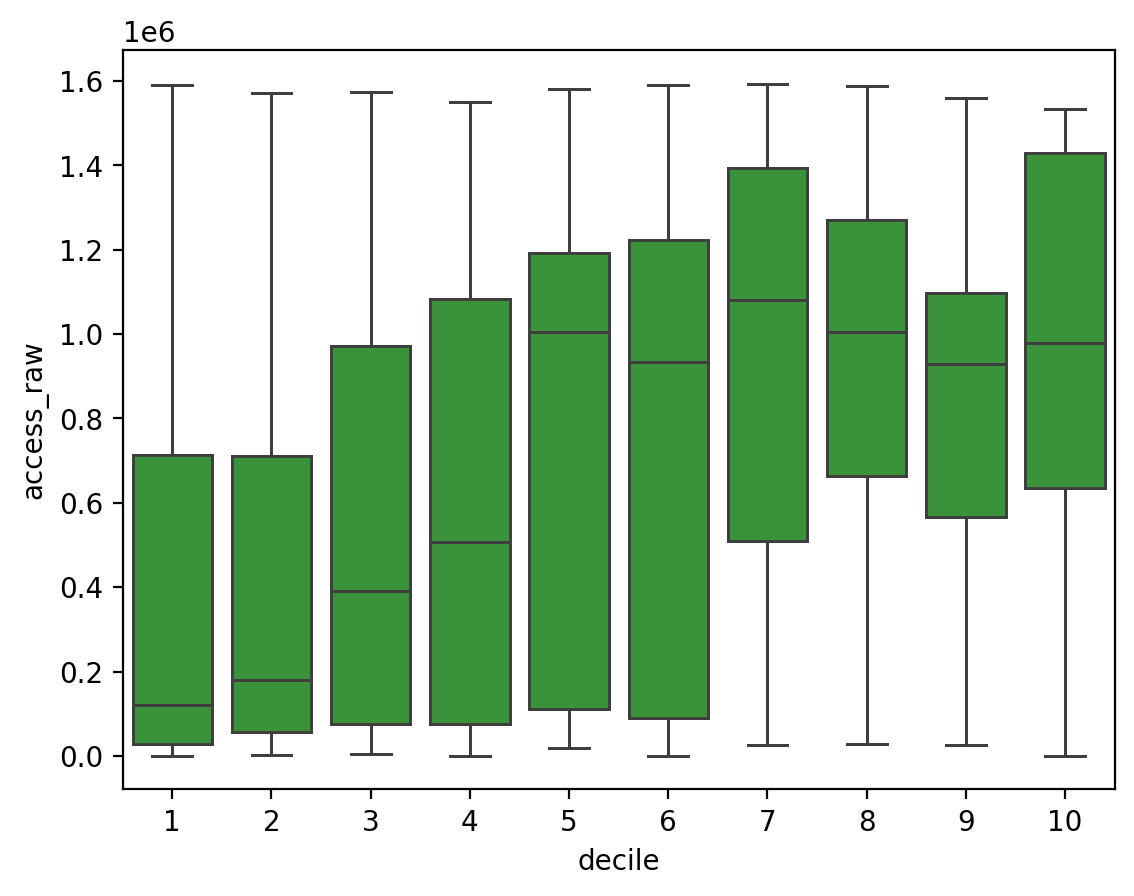

In [33]:
sns.boxplot(
    acc_cum,
    y='access_raw',
    x='decile'
)

plt.show()

In [ ]:
from typing import List
from tobler.area_weighted import area_interpolate

def import_census_2022(ibge_ids: List[int|str], gcloud_id: str) -> gpd.GeoDataFrame:
    query = (
        f"SELECT id_setor_censitario, pessoas, geometria, {', '.join(f'V{i:0>5}' for i in range(644, 657))} "
        "FROM basedosdados.br_ibge_censo_2022.setor_censitario "
        f"WHERE id_municipio IN ({_sql_style_list(ibge_ids)}) "
    )

    data = bd.read_sql(query, billing_project_id=gcloud_id)

    return (
        gpd
        .GeoDataFrame(
            data,
            geometry=gpd.GeoSeries.from_wkt(data["geometria"]),
            crs=4326,
        )
        .drop(columns="geometria")
        .to_crs(31983)
        .rename(
        columns={'pessoas': 'habitantes'}
        )
    )


def _sql_style_list(sequence):
    """
    Converts a list of values into a SQL-style list of single-quoted strings.
    """
    return ", ".join(f"'{item}'" for item in sequence)


In [ ]:
tracts = import_census_2022(ibge_ids, gcloud_id)

In [ ]:

pop_by_age = area_interpolate(
    source_df=tracts.fillna(0),
    target_df=h3fy(
        tracts.assign(geometry=tracts.geometry.buffer(15)),
        resolution=9,
        ),
    extensive_variables=['habitantes'] + [f'V{i:0>5}' for i in range(644, 657)],
    allocate_total=True
)

pop_by_age["age_0_to_14"] = (
    pop_by_age
    .habitantes
    .sub(
        pop_by_age[[f'V{i:0>5}' for i in range(644, 657)]].sum(axis=1),
        axis='index',
        fill_value=0,
        )
    )

pop_by_age["age_15_to_19"] = (
    pop_by_age[['V00644']].sum(axis=1)
    )

pop_by_age["age_60_plus"] = (
    pop_by_age[[f'V{i:0>5}' for i in range(653, 657)]].sum(axis=1)
    )


In [ ]:
pop_by_age.explore('habitantes', cmap='magma', legend=True, scheme='headtailbreaks')

In [ ]:
def bin_trips(ttimes, pop, pop_group='age_0_to_14'):
    bins = np.arange(0, ttimes.min_cost.max() + 1, 1)
    labels = [b for b in bins[1:]]

    ttimes['travel_time_bins'] = pd.cut(
        ttimes['min_cost'].fillna(121),
        bins=bins,
        labels=labels,
        include_lowest=True,
        )

    return (
        pop[[pop_group, 'geometry']]
        .merge(
            ttimes.set_index('hex_id'),
            left_index=True,
            right_index=True,
            )
        .groupby(
            ['travel_time_bins'],
            #as_index=False,
            observed=True,
            )
        .agg({pop_group: 'sum'})
        .astype({
            pop_group: 'int',
            })
        )

In [ ]:
plt.style.use('ggplot')
age_group = 'age_0_to_14'

df = bin_trips(access, pop_by_age, pop_group=age_group)
sns.ecdfplot(x=df.index,weights=df[age_group])
sns.despine()
plt.xlabel("Tempo de Viagem (minutos)")
plt.ylabel("Proporção(%)")
ax = plt.gca()
labels = [f"{tick*100:.0f}" for tick in ax.get_yticks()]
ax.set_yticklabels(labels)
plt.show()



In [ ]:
inpath = tabelas_atributos = (
    '../database/1. Socioeconômicos/sociodemografia_2010.parquet'
)
census_data = gpd.read_parquet(inpath)

In [ ]:
foo = (
    census_data
    #.merge(pop_by_age[['habitantes']], left_index=True, right_index=True)
    .merge(access, left_index=True, right_on='hex_id')
    )

bins = [0, 15, 30, 60, np.inf]
foo['travel_time_bins'], x = pd.cut(
    foo['min_cost'].fillna(np.inf),
    bins=bins,
    labels=bins[:-1],
    include_lowest=True,
    retbins=True
)


In [ ]:
pd.cut(
    foo['min_cost'],
    bins=bins,
    labels=bins[:-1],
    include_lowest=True,
    retbins=True
)



In [ ]:
def reindex_df(df, weight_col):
    df = df.reindex(df.index.repeat(df[weight_col]))
    df.reset_index(drop=True, inplace=True)
    return(df)


def weighted_boxplot(df, weight_col):
    sns.boxplot(x='travel_time_bins', 
                y='rendimento_medio', 
                data=reindex_df(df, weight_col=weight_col),)
    plt.show()

weighted_boxplot(foo, 'habitantes')

In [ ]:
x

In [ ]:
(
    census_data
    .merge(pop_by_age[['age_0_to_14']], left_index=True, right_index=True)
    .merge(access, left_index=True, right_on='hex_id')
    )

In [ ]:
foo.travel_time_bins

In [ ]:
def classify_income_deciles(
        df,
        income_col='rendimento_medio',
        weight_col='habitantes',
        ):
    d = DescrStatsW(df[income_col], weights=df[weight_col])
    # Compute the quantile breakpoints for deciles
    quantiles = [d.quantile(q) for q in np.linspace(0.1, 1.0, 10)]
    bins = [df[income_col].min() - 1] + [float(q) for q in quantiles]
    
    # Assign decile labels 1–10
    return pd.cut(df[income_col], bins=bins, labels=range(1, 11), include_lowest=True)

In [ ]:
classify_income_deciles(census_data)

# Legacy

In [ ]:
from shapely.geometry import Point
from pyproj import Transformer
# Original coordinates are in (lon, lat) WGS84 (EPSG:4326)

transformer = Transformer.from_crs("EPSG:4326", "EPSG:31983", always_xy=True)

d = {
    k: Point(*transformer.transform(pt.x, pt.y))
    for k, pt in {
        '5042488': Point(-43.10111846368994, -22.93496303213362),
        '0113891': Point(-42.97796431846613, -22.82297090020438),
        '0012521': Point(-43.07872347303554, -22.880157833214476),
        '3784916': Point(-42.91998438196854, -22.771568234552003), 
        '0012599': Point(-43.078428218305724, -22.881199876918767),
        '2297590': Point(-43.01194919623843, -22.81838059154707),
        '9101039': Point(-42.95904980987253, -22.84514982733307),
    }.items()
}

for k, pt in d.items():
    pois.at[k, 'geometry'] = pt

pois = pois.drop(index='9101039')